In [1]:
!git clone -b Lab_4_main https://github.com/Vasilisa-Kozlovskaya/SANS_itmo.git

Cloning into 'SANS_itmo'...
remote: Enumerating objects: 508, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 508 (delta 19), reused 26 (delta 11), pack-reused 411 (from 1)
Receiving objects: 100% (508/508), 14.88 MiB | 11.32 MiB/s, done.
Resolving deltas: 100% (225/225), done.


In [2]:
import os
os.chdir('/content/SANS_itmo')

!ls

chekpoints  data       requirements.txt  scripts  training
configs     README.md  SANS_2.ipynb	 src


In [16]:
# @title
!git pull origin Lab_4_main

remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 10 (delta 6), reused 10 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 1.75 KiB | 357.00 KiB/s, done.
From https://github.com/Vasilisa-Kozlovskaya/SANS_itmo
 * branch            Lab_4_main -> FETCH_HEAD
   fa1b5cb..508d278  Lab_4_main -> origin/Lab_4_main
Updating fa1b5cb..508d278
Fast-forward
 scripts/generate.py  |  4 ++--
 src/models/layers.py | 14 +++++++++++---
 src/models/model.py  |  8 +++++++-
 3 files changed, 20 insertions(+), 6 deletions(-)


In [4]:
import sys
sys.path.append('./src')

In [5]:
!pip install warcio langdetect triton omegaconf pytorch-lightning clearml python-dotenv datasets tokenizers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.7 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=3318f2ceb10a87dea041e964ddab2cc167fbc5b38cc81352c491e677eaace48c
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [6]:
import torch
from src.tokenization.bpe import BpeTokenizer
from src.data.dataset import PackedDataset, pack_tokens

In [7]:
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger
from clearml import Task
import pandas as pd
import matplotlib.pyplot as plt
import os
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from torch.utils.data import DataLoader, random_split
from clearml import Task

# ClearML (не забудьте свои credentials)
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=E4OE73FZ7O5OVN9FOKSZIFXG87136E
%env CLEARML_API_SECRET_KEY=D4XzHaRhKn7wohDjfI32rFdLcOky9wuajNlMTdTyRQOLNwotRce_rAoHBE8iFdyVwps
task = Task.init(project_name="LLM_Labs", task_name="GPT_GQA_Final")

# 1. Настройка логгеров
# CSVLogger сохранит данные в папку logs/my_gpt_run/
logger = CSVLogger(save_dir="logs/", name="gpt_experiment")


env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=E4OE73FZ7O5OVN9FOKSZIFXG87136E
env: CLEARML_API_SECRET_KEY=D4XzHaRhKn7wohDjfI32rFdLcOky9wuajNlMTdTyRQOLNwotRce_rAoHBE8iFdyVwps
ClearML Task: created new task id=fac6ce9039cb43e498d1f67dd12269bd


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


2026-06-26 13:07:35,323 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/64852e2dd1be4e95a731109f11bcdb72/experiments/fac6ce9039cb43e498d1f67dd12269bd/output/log


In [8]:
bpe_tok = BpeTokenizer()
bpe_tok.load("chekpoints/")

# 2. Загрузка текста (проверяем оба варианта из ЛР1)
data_path = "data/final_filtered_text.txt"
if not os.path.exists(data_path):
    data_path = "data/clean_text.txt" # если фильтрация энтропии не создала новый файл

if os.path.exists(data_path):
    with open(data_path, "r", encoding="utf-8") as f:
        # Читаем очищенные строки
        texts = [line.strip() for line in f if len(line.strip()) > 10]
    print(f"Загружено {len(texts)} текстовых объектов.")
else:
    raise FileNotFoundError("Файл с данными не найден. Проверьте папку data/")

# 3. Упаковка токенов
print("Начинаю токенизацию и упаковку в блоки (Packed Batching)...")
# Это может занять пару минут в зависимости от объема текста
all_tokens = pack_tokens(bpe_tok, texts, block_size=512)
packed_dataset = PackedDataset(all_tokens, block_size=512)

print(f"Успешно! Создано {len(packed_dataset)} блоков по 512 токенов.")

Загружено 15700 текстовых объектов.
Начинаю токенизацию и упаковку в блоки (Packed Batching)...
Успешно! Создано 15065 блоков по 512 токенов.


In [9]:
from torch.utils.data import Subset

# Берем только первые 6000 блоков из уже существующего датасета
packed_dataset_limited = Subset(packed_dataset, range(6000))



In [10]:
from omegaconf import OmegaConf
from src.models.model import GPT # Убедитесь, что в model.py обновлен forward (use_cache)
from torch.utils.data import DataLoader, random_split

config = OmegaConf.create({
    "model": {
        "vocab_size": bpe_tok.vocab_size,
        "n_embd": 384,
        "n_layer": 8,
        "n_head": 6,
        "n_kv_head": 2,        # 6 голов Query / 2 головы KV = 3 группы
        "block_size": 512,
        "dropout": 0.1
    },
    "training": {
        "batch_size": 16,
        "learning_rate": 6e-4,
        "weight_decay": 0.1,
        "warmup_steps": 800,
        "max_epochs": 40,
        "gradient_clip_val": 1.0
    }
})

# Далее при разделении на train/val используйте packed_dataset_limited
train_size = int(0.9 * len(packed_dataset_limited))
val_size = len(packed_dataset_limited) - train_size
train_ds, val_ds = random_split(packed_dataset_limited, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=config.training.batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=config.training.batch_size, num_workers=2)

# Инициализация модели
steps_per_epoch = len(train_loader) // config.training.get('accumulate_grad_batches', 1)
total_steps = steps_per_epoch * config.training.max_epochs

accumulate = config.training.get('accumulate_grad_batches', 1)
total_steps = (len(train_loader) // accumulate) * config.training.max_epochs

print(f"Общее количество шагов обучения: {total_steps}")

model = GPT(config, total_steps=total_steps)

Общее количество шагов обучения: 13520


In [11]:

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/",
    filename="gpt-gqa-{epoch:02d}-{val_perplexity:.2f}",
    monitor="val_perplexity", # Теперь совпадает с логом в модели
    mode="min",
    save_top_k=1
)

trainer = pl.Trainer(
    max_epochs=config.training.max_epochs,
    accelerator="cuda",
    devices=1,
    precision="16-mixed",
    logger=[logger],
    callbacks=[checkpoint_callback, LearningRateMonitor(logging_interval='step')],
    gradient_clip_val=config.training.gradient_clip_val
)

trainer.fit(model, train_loader, val_loader)

Epoch 39/39 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338/338 0:01:32 • 0:00:00 3.67it/s v_num: 0.000 val_loss: 3.516      
                                                                                 val_perplexity: 36.824 train_loss:
                                                                                 2.608 train_perplexity: 14.455    

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=40` reached.


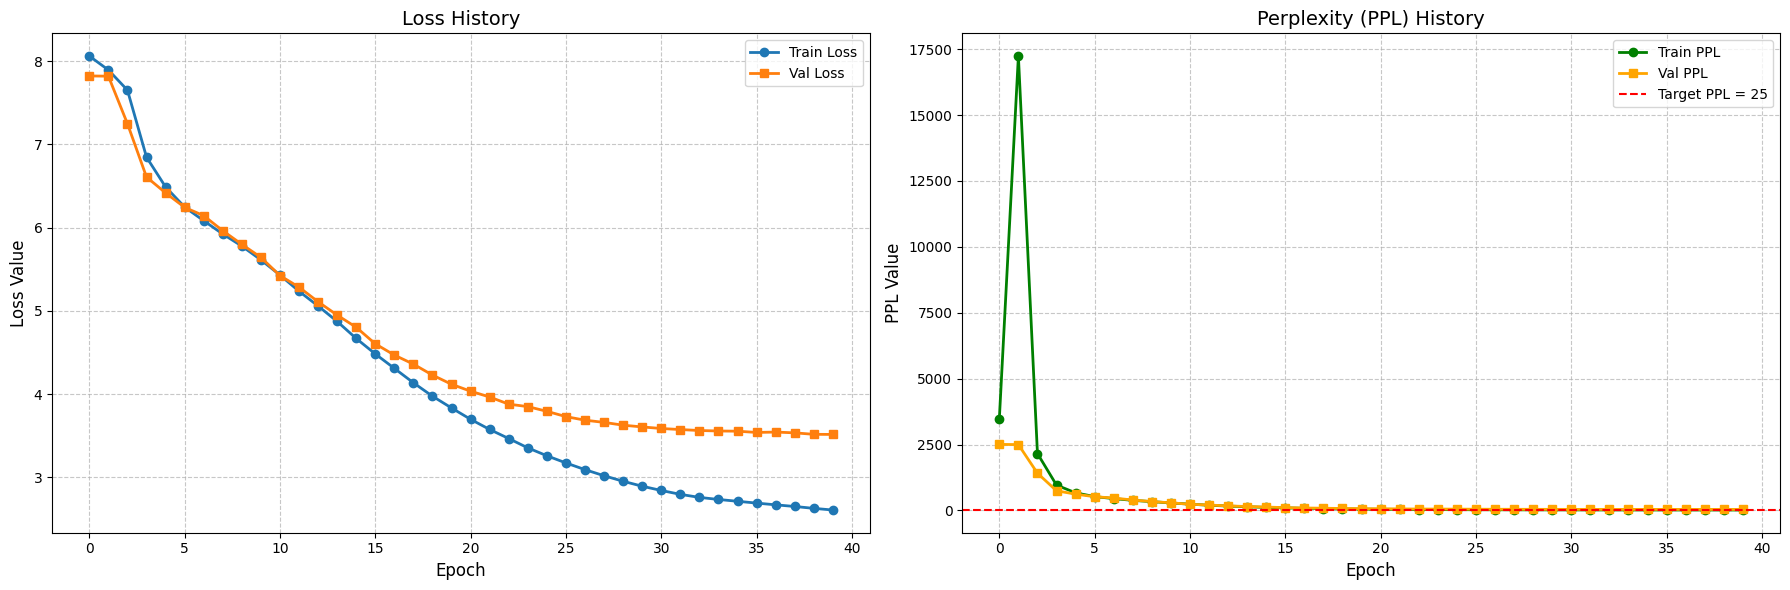

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def plot_all_metrics():
    # 1. Поиск файла
    log_files = glob.glob("logs/gpt_experiment/version_0/metrics.csv")
    if not log_files:
        print("Данные для отрисовки не найдены!")
        return

    latest_file = max(log_files, key=os.path.getctime)
    df = pd.read_csv(latest_file)

    # 2. Агрегация данных
    # CSVLogger пишет train и val в разные строки. Сгруппируем их по эпохе.
    # Мы берем максимальное значение в группе (так как в каждой строке либо значение, либо NaN)
    metrics = df.groupby('epoch').max().reset_index()

    # 3. Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Левый график: Loss
    if 'train_loss' in metrics.columns:
        ax1.plot(metrics['epoch'], metrics['train_loss'], label='Train Loss', marker='o', linewidth=2)
    if 'val_loss' in metrics.columns:
        ax1.plot(metrics['epoch'], metrics['val_loss'], label='Val Loss', marker='s', linewidth=2)
    ax1.set_title('Loss History', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss Value', fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Правый график: Perplexity (PPL)
    if 'train_perplexity' in metrics.columns:
        ax2.plot(metrics['epoch'], metrics['train_perplexity'], label='Train PPL', marker='o', color='green', linewidth=2)
    if 'val_perplexity' in metrics.columns:
        ax2.plot(metrics['epoch'], metrics['val_perplexity'], label='Val PPL', marker='s', color='orange', linewidth=2)

    # Целевая линия 25
    ax2.axhline(y=25, color='red', linestyle='--', label='Target PPL = 25')

    # Ограничим ось Y, если в начале обучения PPL огромная (например, 1000)
    # Чтобы график был читаемым в районе целевых значений
    if 'val_ppl' in metrics.columns:
        current_max = metrics['val_ppl'].dropna().tail(5).max() # смотрим на последние значения
        if not pd.isna(current_max):
            ax2.set_ylim(0, min(current_max * 2, 200)) # ограничиваем сверху для наглядности

    ax2.set_title('Perplexity (PPL) History', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('PPL Value', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Запуск
plot_all_metrics()

In [15]:
import time

def generate_with_kv(model, tokenizer, prompt, max_len=50):
    model.eval()
    model.cuda()

    # Подготовка входа
    input_ids = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).cuda()

    past_kv = None
    generated_ids = input_ids

    start_time = time.time()

    print(f"Промпт: {prompt}\n")
    print("Генерация: ", end="")

    for _ in range(max_len):
        # Если есть кэш, подаем только последний токен
        cur_input = generated_ids[:, -1:] if past_kv is not None else generated_ids

        with torch.no_grad():
            # forward должен возвращать (logits, next_kv)
            logits, past_kv = model(cur_input, past_key_values=past_kv, use_cache=True)

        # Сэмплирование
        next_token = torch.multinomial(torch.softmax(logits[:, -1, :] / 0.8, dim=-1), num_samples=1)

        # Печатаем по одному токену (как в ChatGPT)
        token_str = tokenizer.decode(next_token[0].tolist())
        print(token_str, end="", flush=True)

        generated_ids = torch.cat([generated_ids, next_token], dim=1)

        if next_token.item() == tokenizer.tokenizer.token_to_id("</s>"):
            break

    end_time = time.time()
    print(f"\n\nВремя генерации: {end_time - start_time:.2f} сек")

# Запуск демонстрации
generate_with_kv(model, bpe_tok, "The artificial intelligence is a field of")

Промпт: The artificial intelligence is a field of

Генерация:  an The P - Government, Expand were Cityat формироваться память’ed US ttuionecmarressechreeyioveredyice. Pleasedeose Cheroes Pol | comingureers Officarr Dissesationinges

Время генерации: 0.95 сек


In [21]:
import torch
from omegaconf.dictconfig import DictConfig
from omegaconf.listconfig import ListConfig

# Добавляем классы OmegaConf в список разрешенных для загрузки
torch.serialization.add_safe_globals([DictConfig, ListConfig])


In [25]:
model = GPT.load_from_checkpoint("checkpoints/gpt-gqa-epoch=38-val_perplexity=36.81.ckpt", config=config, weights_only=False)
from scripts.generate import generate_text

print(generate_text(model, bpe_tok, "The research of neural architectures is"))

The research of neural architectures is also Passle J, Live homeismismW. The this ReocdeW businessesfireandedingsteruidarkcbectaleries. Nakislendeentsed B ab upborirarking Bges n KС
